# Do players really outperform in their contract year?

**Companion notebook to [`scripts/experiments/contract_year_effect.py`](../scripts/experiments/contract_year_effect.py)** — that script is the source of truth (tested, see `tests/test_experiments_contract_year_effect.py`); this notebook re-runs the same analysis to show the reasoning visually.

## The question

The "contract year" / "walk year" effect is a well-documented idea in sports economics: a player about to hit free agency has a financial incentive to play his best season. Does it show up in the data enough to be worth adding to this project's projection engine?

## The data

`nba_api` doesn't expose salaries or contracts, so this needed two datasets the user downloaded from Kaggle (`data/raw/contract_data/`, not committed to the repo — see the README): player stats + salary by season (2010-2025), and 199 contracts for 138 players with start/end years. Basketball-Reference and Spotrac both return 403 (anti-bot, their ToS forbids scraping) — that route wasn't attempted.

## The design

Comparing a contract-year season to *other players* doesn't work (every player has their own baseline level). Comparing to the *same player's* adjacent season doesn't fully work either — production rises and falls with age in a predictable way, so a contract year landing near a player's natural peak would look like a "contract year effect" without being one.

So: for contracts spanning >= 2 seasons, compare **Game Score in the final season of the contract** against **Game Score in the other (non-final) seasons of that same contract, for that same player** — isolating the comparison to within-player, within-contract, with an explicit age control.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))
sys.path.insert(0, str(PROJECT_ROOT / "scripts" / "experiments"))

import contract_year_effect as cye
from config_loader import load_config

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"

config = load_config()
panel = cye.build_contract_year_panel(config)
print(f"{panel['contract_id'].nunique()} contracts, {panel['player'].nunique()} distinct players, {len(panel)} player-seasons")
panel.head()


126 contracts, 99 distinct players, 365 player-seasons


,contract_id,player,season_end_year,age,game_score,is_final_year
0,0,Brook Lopez,2016,27,15.62,False
1,0,Brook Lopez,2017,28,14.16,True
2,1,DeAndre Jordan,2012,23,8.39,False
3,1,DeAndre Jordan,2013,24,8.30,False
4,1,DeAndre Jordan,2014,25,12.88,True


## 1. Paired comparison: final year vs. rest of the same contract

For each contract, `delta = GameScore(final year) - mean(GameScore(non-final years))`. If the effect were real, deltas should skew positive.


In [2]:
deltas, t_result = cye.paired_delta_test(panel)
positive = (deltas["delta"] > 0).sum()
print(f"Mean delta: {deltas['delta'].mean():.3f} | Median: {deltas['delta'].median():.3f}")
print(f"Contracts where the final year beat the rest: {positive}/{len(deltas)} ({100*positive/len(deltas):.1f}%)")
print(f"Paired t-test vs. 0: t={t_result.statistic:.3f}, p={t_result.pvalue:.4f}")


Mean delta: -0.170 | Median: -0.605
Contracts where the final year beat the rest: 50/126 (39.7%)
Paired t-test vs. 0: t=-0.763, p=0.4467


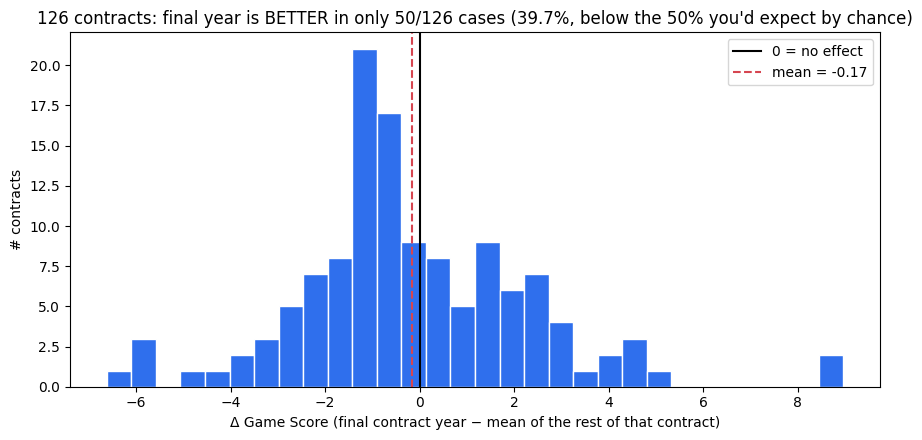

In [3]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(deltas["delta"], bins=30, color="#2f6fed", edgecolor="white")
ax.axvline(0, color="black", linewidth=1.5, label="0 = no effect")
ax.axvline(deltas["delta"].mean(), color="#d64550", linestyle="--", linewidth=1.5, label=f"mean = {deltas['delta'].mean():.2f}")
ax.set_xlabel("Δ Game Score (final contract year − mean of the rest of that contract)")
ax.set_ylabel("# contracts")
ax.set_title(f"126 contracts: final year is BETTER in only {positive}/{len(deltas)} cases ({100*positive/len(deltas):.1f}%, below the 50% you'd expect by chance)")
ax.legend()
plt.tight_layout()
plt.show()


## 2. Fixed-effects regression with an age control

The paired test above already compares within-player, but doesn't explicitly separate "this happened to be a good age for this player" from "this was specifically the contract year". A player-fixed-effects regression (demeaning within player) of `game_score ~ is_final_year + age + age²` does that: the `is_final_year` coefficient can't be explained away by the player's general skill level (fixed effect) or by where they sat on their own age curve.


In [4]:
model = cye.fixed_effects_regression(panel)
print(model.summary().tables[1])
print()
coef = model.params["is_final_year"]
pvalue = model.pvalues["is_final_year"]
print(f"is_final_year coefficient: {coef:.3f} (p={pvalue:.4f}) -- indistinguishable from zero")
print(f"R²: {model.rsquared:.4f}")


                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          1.243e-15      0.091   1.36e-14      1.000      -0.180       0.180
age               3.8353      0.806      4.758      0.000       2.250       5.421
age2             -0.0724      0.014     -5.024      0.000      -0.101      -0.044
is_final_year     0.0319      0.227      0.140      0.888      -0.415       0.479

is_final_year coefficient: 0.032 (p=0.8885) -- indistinguishable from zero
R²: 0.0840


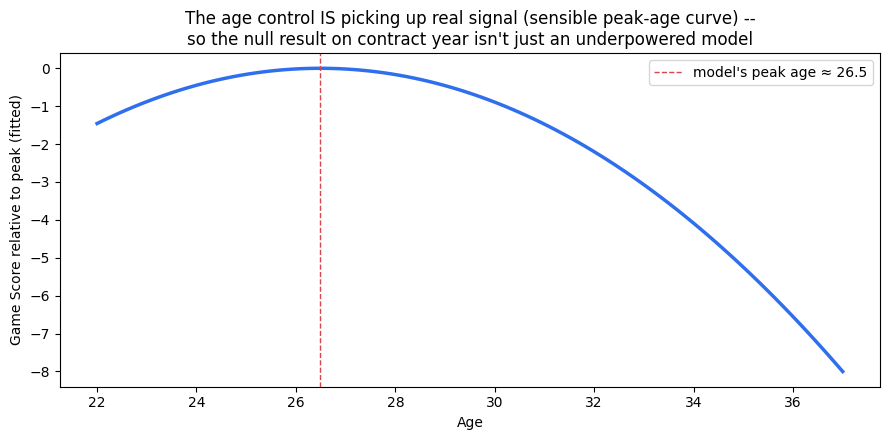

In [5]:
age_coef = model.params["age"]
age2_coef = model.params["age2"]
peak_age = -age_coef / (2 * age2_coef)

ages = np.linspace(panel["age"].min(), panel["age"].max(), 100)
age_curve = age_coef * ages + age2_coef * ages**2
age_curve -= age_curve.max()  # center at the peak for a readable y-axis

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(ages, age_curve, color="#2f6fed", linewidth=2.5)
ax.axvline(peak_age, color="#d64550", linestyle="--", linewidth=1, label=f"model's peak age ≈ {peak_age:.1f}")
ax.set_xlabel("Age")
ax.set_ylabel("Game Score relative to peak (fitted)")
ax.set_title("The age control IS picking up real signal (sensible peak-age curve) --\nso the null result on contract year isn't just an underpowered model")
ax.legend()
plt.tight_layout()
plt.show()


That's an important sanity check: the age term comes back significant with a realistic peak (mid-20s), so this regression *can* detect real effects when they exist. The contract-year coefficient landing at essentially zero (p=0.89) isn't a symptom of a model too weak to find anything — it's a specific null result for this specific question.

## Conclusion

Neither the paired within-contract comparison nor the fixed-effects regression with age controls finds evidence that players outperform in their contract year, on this sample of 126 contracts / 99 players. **Not incorporated into the projection engine.**

Caveats worth stating plainly: the contract sample is partial (only contracts recorded as active/recent around when the Kaggle dataset was scraped, not the league's full history), and if the effect is real but concentrated in a specific subgroup (e.g. mid-rotation players with something to prove, vs. already-max'd stars or replaceable role players with no leverage), this analysis doesn't have the sample size to detect that — it wasn't segmented by player type.
